<a href="https://colab.research.google.com/github/Sunidhikusmi/Customer-Behavior-Analysis/blob/main/CustomerBehaviorAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Behavior Analysis**

This project analyzes customer transaction data to identify customer segments, purchasing behavior, and churn risk using RFM analysis

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Import Libraries

In [49]:
import kagglehub

path = kagglehub.dataset_download("bhanupratapbiswas/customer-behavior-analysis")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'customer-behavior-analysis' dataset.
Path to dataset files: /kaggle/input/customer-behavior-analysis


In [7]:
import os

path = "/root/.cache/kagglehub/datasets/bhanupratapbiswas/customer-behavior-analysis/versions/1" # Corrected path

os.listdir(path)

['ecommerce_customer_data_custom_ratios.csv',
 'ecommerce_customer_data_large.csv']

Load Dataset

In [8]:
import pandas as pd

df = pd.read_csv(path + "/ecommerce_customer_data_large.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


## Data Cleaning and Preparation

In this step, we check for missing values, remove duplicates, and convert data columns into proper datetime format to ensure data accuracy before analysis.

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [41]:
#checking missing values

df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [44]:
df = df.dropna()

In [47]:
df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000
mean,25017.632092,2021-11-06 19:26:22.286192384,254.742724,3.004936,2725.385196,43.798276,0.405904,43.798276,0.20052
min,1.000000,2020-01-01 00:07:26,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,2020-12-03 08:10:12,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,2021-11-06 07:39:08.500000,255.000000,3.000000,2725.000000,44.000000,0.000000,44.000000,0.00000
75%,37441.250000,2022-10-11 01:21:56.249999872,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,2023-09-13 18:42:49,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000
std,14412.515718,NaN,141.738104,1.414737,1442.576095,15.364915,0.491067,15.364915,0.40039


In [48]:
df.mode().head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,48382.0,2020-01-01 15:49:02,Electronics,290.0,4.0,2533.0,Credit Card,47.0,0.0,Michael Johnson,47.0,Male,0.0
1,NaN,2020-01-06 22:26:24,NaN,NaN,NaN,4456.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2020-01-07 03:22:08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2020-01-12 02:11:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,2020-01-12 10:42:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#removing duplicate rows
df = df.drop_duplicates()

In [12]:
#converting purchase date to datetime format

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202618 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

## RFM Feature Engineering

RFM (Recency, Frequency, Monetary) analysis is used to evaluate customer behavior:

- Recency: Days since last purchase
- Frequency: Number of purchase
- Monetary: Total spending amount

This helps in identifying high-value and at-risk customers.

In [14]:
#Creating snapshot date

import datetime as dt

snapshot_date = df['Purchase Date'].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2023-09-14 18:42:49')

In [15]:
#Creating RFM Table

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount' : 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,289,3,6290
2,73,6,16481
3,223,4,9423
4,442,5,7826
5,425,5,9769


In [16]:
rfm.shape

(49661, 3)

In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,49661.000000,49661.000000,49661.000000
mean,262.335374,5.034131,13719.947222
std,246.804539,2.199399,6811.065854
min,1.000000,1.000000,125.000000
25%,78.000000,3.000000,8718.000000
50%,187.000000,5.000000,13008.000000
75%,371.000000,6.000000,17921.000000
max,1352.000000,17.000000,50659.000000


## Customer Segmentation

Customers are segmented based on Recency, Frequency, and Monetary (RFM) score. This approach helps ifd=entify high-value customers, regular customers, and those at risk of churn.

In [19]:
#Creating R,F,M Scores (1 to 4 Ranking)

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [20]:
#Combining Scores

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
1,289,3,6290,2,1,1,211
2,73,6,16481,4,3,3,433
3,223,4,9423,2,2,2,222
4,442,5,7826,1,2,1,121
5,425,5,9769,1,2,2,122


In [21]:
rfm['RFM_Score'].value_counts().head(10)

,count
RFM_Score,
111,4866
444,3476
344,2839
222,2142
211,2122
244,2076
322,2010
122,1910
422,1788


In [22]:
#Converting scores to Integer

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [23]:
#Creating Segment Function

def segment_customer(row):
  if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
    return "Champions"

  elif row['F_score'] >= 3 and row['M_score'] >= 3:
    return "Loyal Customers"

  elif row['R_score'] == 1:
    return "Lost Customers"

  elif row['R_score'] == 2:
    return "At risk"

  else:
    return "Regular Customers"

In [24]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,
1,289,3,6290,2,1,1,211,At risk
2,73,6,16481,4,3,3,433,Champions
3,223,4,9423,2,2,2,222,At risk
4,442,5,7826,1,2,1,121,Lost Customers
5,425,5,9769,1,2,2,122,Lost Customers


In [25]:
rfm['Segment'].value_counts()

,count
Segment,
Regular Customers,13354
Champions,11490
Lost Customers,10668
At risk,8232
Loyal Customers,5917


### Visualization 1: Customer Segmentation (Bar Chart)

This chart shows the distribution of customers across different segments.

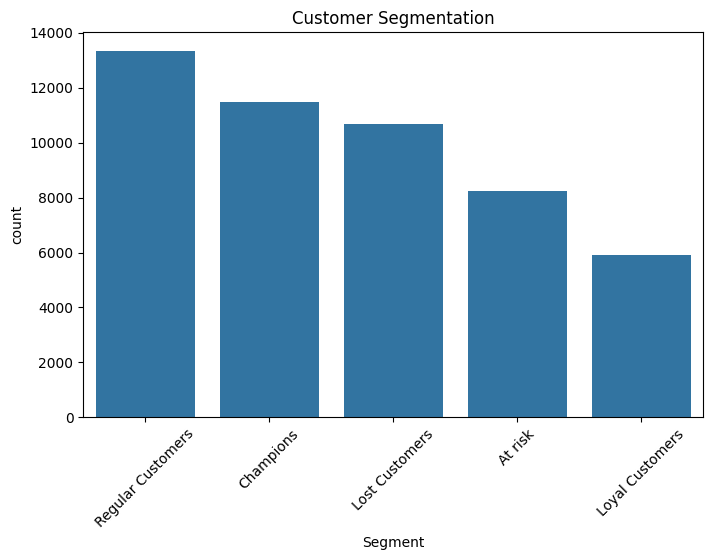

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Customer Segmentation')
plt.show()

### Visualization 2: Sales Trend Over Time (Line Chart)

This line chart shows how total revenue changes over time, helping identify growth or decline trends.


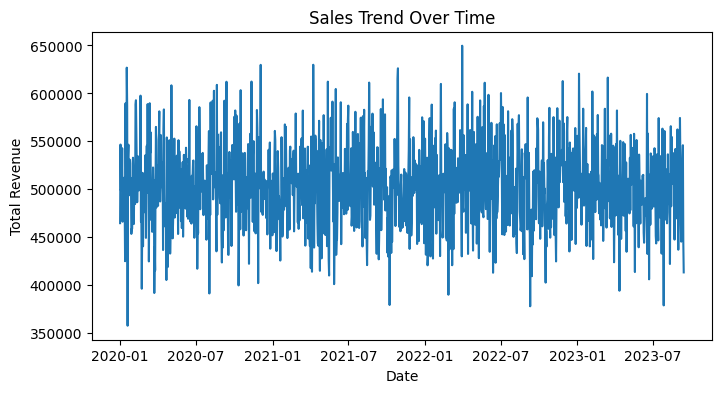

In [39]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

sales_trend = df.groupby(df['Purchase Date'].dt.date)['Total Purchase Amount'].sum()

plt.figure(figsize=(8,4))
sales_trend.plot()
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.show()

### Visualization 3: Purchase Amount Distribution (Histogram)

This histogram shows how transaction amounts are distributed across customers.

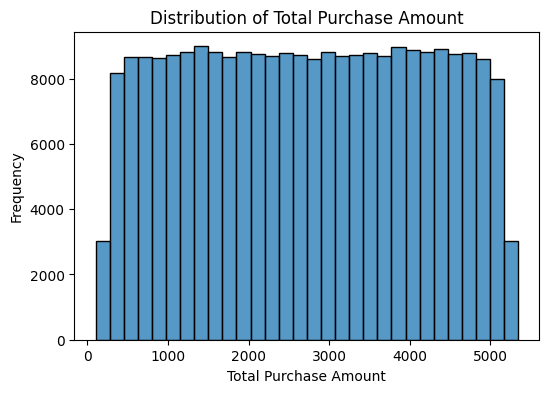

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df['Total Purchase Amount'], bins=30)
plt.title('Distribution of Total Purchase Amount')
plt.xlabel('Total Purchase Amount')
plt.ylabel('Frequency')
plt.show()

## Churn Risk Analysis

Customer with high recency and low engagement are classified as high churn risk. Identifying these customers helps the company take preventive actions.

In [32]:
def churn_risk(row):
  if row['R_score'] == 1:
    return "High Risk"
  elif row['R_score'] == 2:
    return "Medium Risk"
  else:
    return "Low Risk"

rfm['Churn_Risk'] = rfm.apply(churn_risk, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churn_Risk
Customer ID,,,,,,,,,
1,289,3,6290,2,1,1,211,At risk,Medium Risk
2,73,6,16481,4,3,3,433,Champions,Low Risk
3,223,4,9423,2,2,2,222,At risk,Medium Risk
4,442,5,7826,1,2,1,121,Lost Customers,High Risk
5,425,5,9769,1,2,2,122,Lost Customers,High Risk


In [33]:
rfm['Churn_Risk'].value_counts()

,count
Churn_Risk,
Low Risk,24844
Medium Risk,12419
High Risk,12398


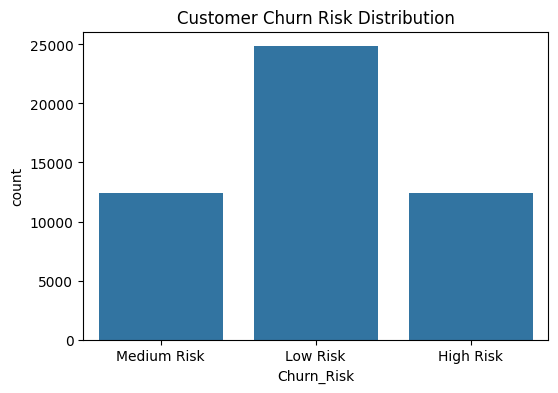

In [34]:
import matplotlib.pyplot as plt
import seaborn

plt.figure(figsize=(6,4))
sns.countplot(x='Churn_Risk', data=rfm)
plt.title('Customer Churn Risk Distribution')
plt.show()


In [35]:
rfm.groupby('Churn_Risk')['Monetary'].sum()

,Monetary
Churn_Risk,
High Risk,126158393
Low Risk,384809466
Medium Risk,170378440


# Business Summary for Alfido Tech

## Overview

This analysis explores customer transaction data to understand purchasing behaviour, revenue trends, and churn risk patterns using statistical analysis and visualizations.

## Key Insights

1.   Revenue Concentration: A significant portion of revenue is generated by highly engaged customer segments. Retaining these customers is crucial for business stability.

2.   Sales Trend Behavior: Revenue patterns fluctuate over time,m indicating the importance of monitoring seasonal or behavioral changes in puchasing.

3.  Churn Risk Identification: A noticeable number of customers fall into the high churn risk category. Proactive retention strategeies can help reduce potential revenue loss.

## Conclusion

Understanding customer segments, purchase trends, and churn risk enables data-driven decisions to improve retention and long term profitability.